<br>
<font>
<div dir=ltr align=center>
<font color=white size=15>
    Numerical Computations <br>
<font color=Red size=6>
    Numerical Solution for System(s)<br>
<font color=white size=3>
    Hamid Sarbazi-Azad & Samira Hossein Ghorban <br>
    Department of Computer Engineering <br>
    Sharif University of Technology (SUT) <br>
    Tehran, Iran <br>

<font color=696880 size=2>
Amirreza Aranpour
<!-- <img src='http://www-scf.usc.edu/~ghasemig/images/sharif.png' alt="SUT logo" width=300 height=300 align=center class="saturate" > -->

# 1- Solutions of Equations in One variable

When dealing with mathematical problems, it's often necessary to find values for a single variable that satisfy a particular equation. These equations, which involve only one variable, can be written in the form $f(x) = 0$, where $x$ is the variable we want to solve for, and $f(x)$ is some mathematical expression or function that depends on $x$.

The process of finding these values of $x$ that make the equation true is what we refer to as "solving equations in one variable". These equations and their solutions are fundamental in various fields of mathematics, science, and engineering.

To find these solutions, we often employ numerical methods when analytical solutions are not readily available or are too complex to compute by hand. Numerical methods provide us with approximate solutions that are sufficiently accurate for practical purposes. One such method is the bisection method, which iteratively narrows down an interval containing the root of the equation until a satisfactory approximation is achieved.

In summary, solving equations in one variable involves finding values of $x$ that satisfy an equation of the form $f(x) = 0$, and numerical methods like the bisection method are used when analytical solutions are challenging to obtain. These methods are essential tools in problem-solving across a wide range of disciplines.

## 1.1- Fixed-Point Iteration

Fixed-Point Iteration is a numerical method used to find solutions to equations of the form $f(x) = 0$. It works by reformulating the problem into the form $x = g(x)$, where $g(x)$ is a function.

The method begins with an initial guess, denoted as $x_0$. It then iteratively updates the guess using the formula $x_{n+1} = g(x_n)$ until a satisfactory solution is reached. Convergence is achieved when the difference between consecutive approximations, $|x_{n+1} - x_n|$, becomes smaller than a predefined tolerance or when a maximum number of iterations is reached.

The choice of the function $g(x)$ is crucial, as convergence depends on it. While Fixed-Point Iteration may not always guarantee convergence or may converge slowly, it remains a valuable numerical tool for solving equations when other methods are not applicable.

**Example:**

Let's consider an example where we want to find a root of the equation $f(x) = x^2 - x - 5 = 0$ using the Fixed-Point Iteration method.

Reformulating the Equation:

To apply Fixed-Point Iteration, we need to rewrite the equation in the form $x = g(x)$. In this case, we can rearrange the equation as follows:

\begin{equation}
    x = \sqrt{5 + x}
\end{equation}

Now, we have our function $g(x)$:

\begin{equation}
    g(x) = \sqrt{5 + x}
\end{equation}


In [1]:
def fixed_point_iteration(g, initial_guess, tolerance, max_iterations):
    x = initial_guess
    iteration = 0

    while iteration < max_iterations:
        x_new = g(x)
        iteration += 1
        if abs(x_new - x) < tolerance:
            return x_new, iteration
        x = x_new

    return None, iteration  # If the method doesn't converge within max_iterations

# Define the function g(x)
def g(x):
    return (5 + x)**0.5

# Set initial guess, tolerance, and maximum number of iterations
initial_guess = 1.0
tolerance = 1e-6
max_iterations = 100

# Find the approximate root using Fixed-Point Iteration
approx_root, num_iterations = fixed_point_iteration(g, initial_guess, tolerance, max_iterations)

if approx_root is not None:
    print(f"Approximate Root: {approx_root}")
    print(f"Number of iterations: {num_iterations}")
else:
    print("Fixed-Point Iteration did not converge within the specified iterations.")


Approximate Root: 2.79128778168858
Number of iterations: 10


# 2- Gradient Descent

**Gradient Descent** is an optimization algorithm used to minimize a cost function. Here are the key components:

1. **Objective Function**: Start with a cost function $J(\theta_0, \theta_1)$ that depends on model parameters $\theta_0$ and $\theta_1$.

2. **Gradient Calculation**: Calculate the gradient (or derivative) of the cost function with respect to the parameters:

\begin{align*}
    \nabla J(\theta_0, \theta_1) = \left(\frac{\partial J}{\partial \theta_0}, \frac{\partial J}{\partial \theta_1}\right)
\end{align*}

   The gradient indicates the steepest ascent in the cost function.

3. **Update Rule**: Adjust the parameters $\theta_0$ and $\theta_1$ in the opposite direction of the gradient by a factor of the learning rate $\alpha$:

\begin{align*}
   \theta_0 &= \theta_0 - \alpha \frac{\partial J}{\partial \theta_0} \\
   \theta_1 &= \theta_1 - \alpha \frac{\partial J}{\partial \theta_1}
\end{align*}

   The learning rate $\alpha$ controls the step size of each iteration.

4. **Iterate**: Repeat the gradient calculation and parameter updates for a specified number of iterations or until convergence criteria are met.

**Example:**

Suppose you are fitting a simple linear regression model with parameters $\theta_0$ (intercept) and $\theta_1$ (slope). The cost function in this case is the Mean Squared Error (MSE):

\begin{align*}
J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} \left(h_{\theta}(x^{(i)}) - y^{(i)}\right)^2
\end{align*}

Where:
- $J(\theta_0, \theta_1)$ is the cost function.
- $h_{\theta}(x^{(i)})$ is the model's prediction for the $i$-th data point.
- $y^{(i)}$ is the actual target value for the $i$-th data point.
- $m$ is the number of data points.

The Gradient Descent algorithm is used to find the optimal values of $\theta_0$ and $\theta_1$ that minimize the cost function, making the model's predictions as close as possible to the actual target values.

In [2]:
import numpy as np

# Generate some sample data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.rand(100, 1)

# Define the number of iterations and the learning rate
num_iterations = 1000
learning_rate = 0.1

# Initialize model parameters (slope and intercept)
theta0 = np.random.rand(1)
theta1 = np.random.rand(1)

# Perform Gradient Descent
for iteration in range(num_iterations):
    predictions = theta0 + theta1 * X
    errors = predictions - y

    # Calculate gradients
    gradient0 = (1/len(X)) * np.sum(errors)
    gradient1 = (1/len(X)) * np.sum(errors * X)

    # Update parameters
    theta0 = theta0 - learning_rate * gradient0
    theta1 = theta1 - learning_rate * gradient1

# The optimized parameters represent the best-fit line
print("Optimized parameters:")
print("Theta0:", theta0[0])
print("Theta1:", theta1[0])

Optimized parameters:
Theta0: 4.558079912151289
Theta1: 2.9682756294878994


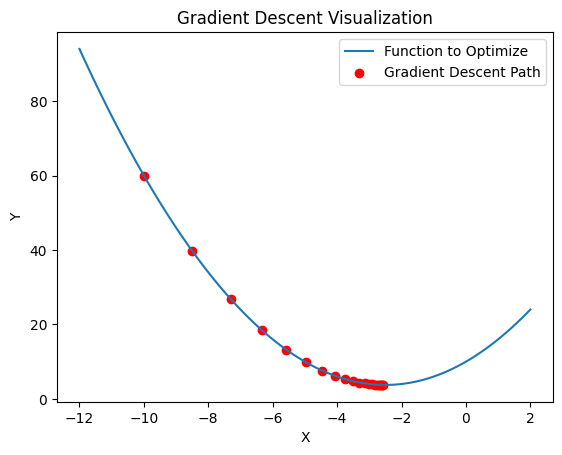

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def function_to_optimize(x):
    # Define the function you want to optimize
    return x**2 + 5*x + 10

def gradient_descent(initial_x, learning_rate, num_iterations):
    x_values = [initial_x]
    for _ in range(num_iterations):
        current_x = x_values[-1]
        gradient = 2 * current_x + 5  # Derivative of the function_to_optimize
        new_x = current_x - learning_rate * gradient
        x_values.append(new_x)

    return x_values

# Parameters for gradient descent
initial_x = -10
learning_rate = 0.1
num_iterations = 20

# Run gradient descent
x_values = gradient_descent(initial_x, learning_rate, num_iterations)

# Plotting the function and the gradient descent path
x_range = np.linspace(-12, 2, 100)
y_values = function_to_optimize(x_range)

plt.plot(x_range, y_values, label='Function to Optimize')
plt.scatter(x_values, [function_to_optimize(x) for x in x_values], color='red', label='Gradient Descent Path')
plt.title('Gradient Descent Visualization')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()


In this example, we have a quadratic function $\text{function_to_optimize}(x) = x^2 + 5x + 10 $, and we use gradient descent to find the minimum of this function. The visualization includes the function plot and the path taken by the gradient descent algorithm.


## 2.1- Learning Rate


The learning rate is a crucial hyperparameter in gradient descent algorithms. It controls the step size during optimization. Choosing an appropriate learning rate is essential for successful convergence. A too-large learning rate may lead to instability, while a too-small one may result in very slow convergence. Finding the right balance is vital for efficient training.

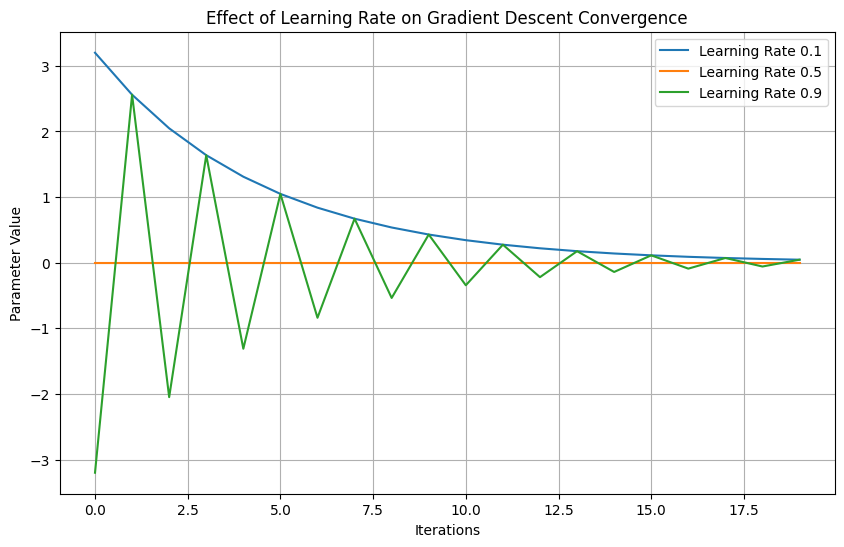

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define a sample cost function (for illustration)
def cost_function(x):
    return x**2

# Gradient Descent function for illustration (you'd replace this with your actual model training)
def gradient_descent(learning_rate, num_iterations):
    history = []
    x = 4.0  # Initial guess
    for _ in range(num_iterations):
        gradient = 2 * x  # Gradient of the cost function (d(cost_function)/dx)
        x -= learning_rate * gradient  # Update x using the learning rate
        history.append(x)
    return history

# Learning rates to test
learning_rates = [0.1, 0.5, 0.9]

# Number of iterations
num_iterations = 20

# Create a chart to visualize the effect of learning rates on convergence
plt.figure(figsize=(10, 6))
for learning_rate in learning_rates:
    history = gradient_descent(learning_rate, num_iterations)
    plt.plot(history, label=f'Learning Rate {learning_rate}')

plt.title('Effect of Learning Rate on Gradient Descent Convergence')
plt.xlabel('Iterations')
plt.ylabel('Parameter Value')
plt.legend()
plt.grid(True)
plt.show()

# 3- Newton-Raphson

The Newton-Raphson method is an iterative approach for finding the root (solution) of an equation $f(x) = 0$. It uses the following formula to update an initial guess $x_n$ to get a more accurate approximation $x_{n+1}$ of the root:

\begin{align*}
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
\end{align*}

Where:
- $x_n$ is the current approximation of the root.
- $x_{n+1}$ is the next approximation, hopefully closer to the actual root.
- $f(x_n)$ is the function value at $x_n$.
- $f'(x_n)$ is the derivative of the function at $x_n$.

**Example:**

Let's apply the Newton-Raphson method to find an approximation of the square root of a number, say 5. We want to find a root of the equation $f(x) = x^2 - 5 = 0$. The derivative of $f(x)$ is $f'(x) = 2x$.

1. Choose an initial guess, $x_0$. Let's start with $x_0 = 2$.

2. Apply the Newton-Raphson formula:

\begin{align*}
   x_1 &= x_0 - \frac{f(x_0)}{f'(x_0)}\\
   x_1 &= 2.0 - \frac{2.0^2 - 5}{2 \cdot 2.0} = 2.0 - \frac{4.0-5}{4.0} = 2.0 + 0.25 =2.25
\end{align*}

3. Repeat the process:
   - $x_2 = 2.25 - \frac{2.25^2 - 5}{2 \cdot 2.25} ≈ 2.2361$
   - $x_3 = 2.2361 - \frac{2.2361^2 - 5}{2 \cdot 2.2361} ≈ 2.2361$
   - ...

In this example, the Newton-Raphson method converges to an approximation of the square root of 5, which is approximately 2.2361. The method provides an accurate result different from the initial guess and demonstrates how it can find a different root.

In [5]:
# Define the function and its derivative
def f(x):
    return x**2 - 5

def df(x):
    return 2 * x

# Newton-Raphson method
def newton_raphson(initial_guess, tol=1e-6, max_iterations=100):
    x = initial_guess
    for i in range(max_iterations):
        x = x - f(x) / df(x)
        if abs(f(x)) < tol:
            return x
    return None  # Return None if the method doesn't converge

# Set the initial guess
initial_guess = 2.0

# Call the Newton-Raphson method
result = newton_raphson(initial_guess)

if result is not None:
    print(f"Approximate square root of 5: {result:.6f}")
else:
    print("Newton-Raphson method did not converge.")

Approximate square root of 5: 2.236068


# 4- Solving Linear Systems

In the realm of mathematics and engineering, the exploration of linear systems is of utmost importance owing to its widespread relevance in real-world problem-solving. Linear systems, characterized by algebraic equations with variables raised to the power of one, necessitate the identification of a singular set of values for these variables that collectively fulfill all specified equations. The pursuit of exact solutions to linear systems involves employing diverse methodologies, including Gaussian elimination, matrix factorization, and eigendecomposition. These techniques offer versatile approaches to uncovering precise solutions and contribute significantly to the understanding and resolution of linear systems in a variety of applications.

## 4.1- Exact Solution of Linear Systems

In the study of linear systems, the focus is on solving a set of m equations in n variables, characterized by the form $E_i: a_{i1}x_1 + a_{i2}x_2 + \ldots + a_{in}x_n = b_i$. Three operations—multiplication of an equation by a constant, addition of a multiple of one equation to another, and transposition of equations—are employed to simplify linear systems. These operations preserve solutions while facilitating systematic transformation for easier resolution. The transition to matrix representation enhances computational efficiency. In contrast, the exploration of non-linear systems, where variables are raised to powers other than one, requires innovative techniques such as numerical methods and iterative algorithms. This intricate realm poses challenges that, when addressed, offer valuable insights into system behavior.

**Formula**:

\begin{align*}
E_i: a_{i1}x_1 + a_{i2}x_2 + \ldots + a_{in}x_n = b_i
\end{align*}

**Example**:

Consider the following linear system:

\begin{align*}
E_1&: 2x + 3y - 4z = 9 \\
E_2&: x + y + z = 1 \\
E_3&: 4x - 2y + 2z = 2
\end{align*}

In [6]:
def gaussian_elimination(A, b):
    if not A or len(A) != len(b) or any(len(row) != len(A) for row in A):
        raise ValueError("A must be a nonempty square matrix and len(b) must match it.")
    matrix_scale = max(abs(value) for row in A for value in row)
    if matrix_scale == 0:
        raise ValueError("The coefficient matrix is singular.")

    # Augmenting the coefficient matrix with the right-hand side vector
    augmented_matrix = [row + [bi] for row, bi in zip(A, b)]

    # Forward elimination with partial pivoting
    for i in range(len(augmented_matrix)):
        pivot_row = max(range(i, len(augmented_matrix)), key=lambda r: abs(augmented_matrix[r][i]))
        if abs(augmented_matrix[pivot_row][i]) <= 1e-12 * matrix_scale:
            raise ValueError("The coefficient matrix is singular.")
        augmented_matrix[i], augmented_matrix[pivot_row] = augmented_matrix[pivot_row], augmented_matrix[i]

        # Make the diagonal element 1
        divisor = augmented_matrix[i][i]
        augmented_matrix[i] = [elem / divisor for elem in augmented_matrix[i]]

        # Eliminate other elements in the current column
        for j in range(i + 1, len(augmented_matrix)):
            factor = augmented_matrix[j][i]
            augmented_matrix[j] = [elemj - factor * elemi for elemi, elemj in zip(augmented_matrix[i], augmented_matrix[j])]

    # Backward substitution
    x = [0] * len(A)
    for i in range(len(augmented_matrix) - 1, -1, -1):
        x[i] = augmented_matrix[i][-1]
        for j in range(i + 1, len(augmented_matrix)):
            x[i] -= augmented_matrix[i][j] * x[j]

    return x

# Example linear system
A = [[2, 3, -4], [1, 1, 1], [4, -2, 2]]
b = [9, 1, 2]

# Solve using Gaussian elimination
solution = gaussian_elimination(A, b)
print("Solution:", solution)

Solution: [1.368421052631579, 0.6842105263157896, -1.0526315789473684]


This code implements Gaussian elimination without using NumPy, showcasing the fundamental steps of forward elimination and backward substitution. Adjust the coefficients and right-hand side values as needed for different systems.

In [7]:
import numpy as np

# Coefficient matrix
A = np.array([[2, 3, -4], [1, 1, 1], [4, -2, 2]])

# Right-hand side
b = np.array([9, 1, 2])

# Solve using NumPy's linear algebra solver
solution = np.linalg.solve(A, b)
print("Solution:", solution)

Solution: [ 1.36842105  0.68421053 -1.05263158]


This example demonstrates solving a linear system using the NumPy library in Python, showcasing the application of matrices and efficient computational techniques for obtaining exact solutions. Adjust coefficients and right-hand side values for different systems.

## 4.2- Matrices and vectors

A matrix is a two-dimensional array of numbers organized into rows and columns, denoted as an $m \times n$ matrix, where $m$ is the number of rows and $n$ is the number of columns. Elements of a matrix are individual items within it. A square matrix has equal rows and columns. The main diagonal consists of elements $a_{i,i}$, forming a line from the upper left to the lower right. A matrix with one row and $n$ elements is an $n$-dimensional row vector, while one column and $n$ elements make an $n$-dimensional column vector. These vectors find applications in diverse fields due to their ability to compactly represent and manipulate multiple variables simultaneously.

- **Matrix:**
$A =
\begin{bmatrix}
a_{11} & a_{12} & \ldots & a_{1n} \\
a_{21} & a_{22} & \ldots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \ldots & a_{mn}
\end{bmatrix}$
  
- **Row Vector:** $y^T = \begin{bmatrix} y_1 & y_2 & \cdots & y_n \end{bmatrix}$

- **Column Vector:** $ x = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix}$

**Example**:

Consider a matrix $A$ and vectors $x$ and $y$:

\begin{align*}
A =
\begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6 \\
7 & 8 & 9
\end{bmatrix}
,x =
\begin{bmatrix}
1 \\
2 \\
3
\end{bmatrix},
y^T = \begin{bmatrix} 4 & 5 & 6 \end{bmatrix}
\end{align*}

### 4.2.1- Special types of square matrices

1. **Diagonal Matrix:**
   - **Formula:** A square matrix $D$ is diagonal if $d_{ij} = 0$ for all $i \neq j$.
   - **Example:**

   $ D = \begin{bmatrix} 3 & 0 & 0 \\ 0 & 8 & 0 \\ 0 & 0 & -2 \end{bmatrix} $
2. **Upper Triangular Matrix:**
   - **Formula:** A square matrix $U$ is upper triangular if $u_{ij} = 0$ for all $i > j$.
   - **Example:**

   $ U = \begin{bmatrix} 1 & 4 & 7 \\ 0 & 5 & 8 \\ 0 & 0 & 9 \end{bmatrix} $

3. **Lower Triangular Matrix:**
   - **Formula:** A square matrix $L$ is lower triangular if $l_{ij} = 0$ for all $i < j$.
   - **Example:**

   $ L = \begin{bmatrix} 2 & 0 & 0 \\ 6 & 5 & 0 \\ 1 & -3 & 9 \end{bmatrix} $

## 4.3- Gaussian Elimination

Gaussian elimination is a standard procedure for transforming an $m \times n$ matrix $M$ over a field $F$ into row echelon form. Gauss--Jordan elimination continues the process to obtain reduced row echelon form. The process uses elementary row operations, including scaling a row by a nonzero field element, subtracting a multiple of one row from another, and swapping two rows. A matrix in row echelon form has the following characteristics:
- Rows entirely consisting of zeros are positioned at the bottom.
- The leading nonzero entry (pivot) of each nonzero row lies strictly to the right of the pivot in the row above it.
- Every entry below each pivot is zero. (In reduced row echelon form, each pivot is 1 and is the only nonzero entry in its column.)

**Formula**:

The elementary row operations are:
1. **Scaling a Row:** Multiply a row by the inverse of the left-most non-zero element in the row.
2. **Row Subtraction:** Subtract a multiple of one row from another to create a new left-most zero element.
3. **Row Swapping:** Swap two rows to reposition a new non-zero pivot element at the top.

**Example**:

Consider the matrix $M$ before and after Gaussian elimination:
$ M = \begin{bmatrix} 2 & 3 & 1 \\ 4 & 7 & 3 \\ 6 & 8 & 9 \end{bmatrix} $

In [8]:
# Example matrix
M = [
    [2, 3, 1],
    [4, 7, 3],
    [6, 8, 9]
]

# Gaussian elimination with partial pivoting
def row_echelon_form(matrix, tolerance=1e-12):
    matrix = [[float(value) for value in row] for row in matrix]
    rows, columns = len(matrix), len(matrix[0])
    pivot_row = 0

    for column in range(columns):
        if pivot_row == rows:
            break
        best_row = max(range(pivot_row, rows), key=lambda r: abs(matrix[r][column]))
        if abs(matrix[best_row][column]) <= tolerance:
            continue
        matrix[pivot_row], matrix[best_row] = matrix[best_row], matrix[pivot_row]

        pivot = matrix[pivot_row][column]
        matrix[pivot_row] = [value / pivot for value in matrix[pivot_row]]
        for row in range(pivot_row + 1, rows):
            factor = matrix[row][column]
            matrix[row] = [value - factor * pivot_value for value, pivot_value in zip(matrix[row], matrix[pivot_row])]
        pivot_row += 1

    return matrix

# Apply Gaussian elimination
result_matrix = row_echelon_form(M)

# Display the original and result matrices
print("Original Matrix:")
for row in M:
    print(row)
print("\nMatrix after Gaussian Elimination:")
for row in result_matrix:
    print(row)


Original Matrix:
[2, 3, 1]
[4, 7, 3]
[6, 8, 9]

Matrix after Gaussian Elimination:
[1.0, 1.3333333333333333, 1.5]
[0.0, 1.0, -1.7999999999999996]
[-0.0, -0.0, 1.0]


## 4.4- The Determinant of a Matrix

The determinant of a square matrix is a scalar value that provides information about the matrix's properties. It is denoted as $\text{det}(A)$ or $\lvert A \rvert$. The determinant is defined for matrices of size $n \times n$. The formula for a 2x2 matrix is $\text{det}(A) = ad - bc$, and for larger matrices, various methods like cofactor expansion or LU decomposition can be employed. The determinant is used in various mathematical and engineering applications, such as solving systems of linear equations and calculating eigenvalues.

**Formula**:

For a 2x2 matrix $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$:
$ \text{det}(A) = ad - bc $

For a general n x n matrix $A$, the determinant can be computed using methods like cofactor expansion or LU decomposition.

**Example**:

Consider a 3x3 matrix:
$ A = \begin{bmatrix} 2 & 3 & 1 \\ 4 & 7 & 3 \\ 6 & 8 & 9 \end{bmatrix} $

In [9]:
def determinant(matrix):
    # Base cases
    if len(matrix) == 1 and len(matrix[0]) == 1:
        return matrix[0][0]
    if len(matrix) == 2 and len(matrix[0]) == 2:
        return matrix[0][0] * matrix[1][1] - matrix[0][1] * matrix[1][0]

    det = 0
    for i in range(len(matrix)):
        # Create submatrix by excluding the current row and column
        submatrix = [row[:i] + row[i + 1:] for row in matrix[1:]]

        # Alternate signs for cofactor expansion
        sign = (-1) ** i

        # Recursive call to calculate the determinant
        det += sign * matrix[0][i] * determinant(submatrix)

    return det

# Example matrix
A = [[2, 3, 1], [4, 7, 3], [6, 8, 9]]

# Calculate determinant without NumPy
det_A = determinant(A)

# Display the matrix and determinant
print("Matrix A:")
for row in A:
    print(row)
print("\nDeterminant of A:", det_A)

Matrix A:
[2, 3, 1]
[4, 7, 3]
[6, 8, 9]

Determinant of A: 14


This code defines a `determinant` function using a recursive approach for general nxn matrices. Adjust the values in the `A` matrix for different examples.